In [16]:
import json
import os
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 6})

import sys
sys.path.append('..')

import warnings
warnings.filterwarnings("ignore")

from omegaconf import OmegaConf

from probssl.data.base import prepare_data
from probssl.methods import METHODS
from probssl.utils.offline_model_eval import get_states_and_decodings

from probssl.data.dot_motion import get_video_frames, save_videos_as_gifs_and_pdfs

# seed everything
from lightning.pytorch import seed_everything

In [17]:
def get_loader(model_name):
    seed_everything(3, workers=True)

    folder_name = "../trained_models/" + model_name + "/"
    # get name of the most recent model by folder creation time
    name = sorted(os.listdir(folder_name), key=lambda x: os.path.getctime(os.path.join(folder_name, x)))[-1]

    pretrained_checkpoint_dir = folder_name + name
    args_file = os.path.join(pretrained_checkpoint_dir, "args.json")
    args = json.load(open(args_file, "r"))
    cfg = OmegaConf.create(args)

    # prepare data
    _, val_loader = prepare_data(cfg)

    return val_loader

def load_model_and_data(model_name, val_loader):
    seed_everything(3, workers=True)

    folder_name = "../trained_models/" + model_name + "/"
    # get name of the most recent model by folder creation time
    name = sorted(os.listdir(folder_name), key=lambda x: os.path.getctime(os.path.join(folder_name, x)))[-1]

    pretrained_checkpoint_dir = folder_name + name
    args_file = os.path.join(pretrained_checkpoint_dir, "args.json")
    args = json.load(open(args_file, "r"))
    cfg = OmegaConf.create(args)

    # build paths
    ckpt_dir = Path(pretrained_checkpoint_dir)  
    args_path = ckpt_dir / "args.json"
    ckpt_path = [ckpt_dir / ckpt for ckpt in os.listdir(ckpt_dir) if ckpt.endswith(".ckpt")][0]

    # load arguments
    with open(args_path) as f:
        method_args = json.load(f)
    cfg = OmegaConf.create(method_args)
    cfg.optimizer.batch_size = 8 # set batch size to 8 for evaluation

    # build the model
    model = (
        METHODS[method_args["method"]]
        .load_from_checkpoint(ckpt_path, strict=False, cfg=cfg)
    )

    # move model to the gpu
    device = "cuda:0"
    model = model.to(device)

    # get images and features
    data, labels, latents, decodings = get_states_and_decodings(device, model, val_loader)

    return data, labels, latents, decodings, model, cfg


In [18]:
# model name is 
model_name = "kalmanSSL_inferred_sigmas"
loader = get_loader(model_name)
data_inferred, labels_inferred, latents_inferred, decodings_inferred, model_inferred, cfg_inferred = load_model_and_data(model_name, loader)

model_name = "kalmanSSL_figure8_procrustes"
loader = get_loader(model_name)
data_8_ent, labels_8_ent, latents_8_ent, decodings_8_ent, model_8_ent, cfg_8_ent = load_model_and_data(model_name, loader)

model_name = "kalmanSSL_figure8"
data_8_stpgr, labels_8_stpgr, latents_8_stpgr, decodings_8_stpgr, model_8_stpgr, cfg_8_stpgr = load_model_and_data(model_name, loader)

model_name = "square_kalmanSSL_procrustes"
loader = get_loader(model_name)
data_square_ent, labels_square_ent, latents_square_ent, decodings_square_ent, model_square_ent, cfg_square_ent = load_model_and_data(model_name, loader)

model_name = "square_kalmanSSL"
loader = get_loader(model_name)
data_square_stpgr, labels_square_stpgr, latents_square_stpgr, decodings_square_stpgr, model_square_stpgr, cfg_square_stpgr = load_model_and_data(model_name, loader)

model_dict = {
    "kalmanSSL_inferred_sigmas": (data_inferred, labels_inferred, latents_inferred, decodings_inferred, model_inferred, cfg_inferred),
    "kalmanSSL_figure8_procrustes": (data_8_ent, labels_8_ent, latents_8_ent, decodings_8_ent, model_8_ent, cfg_8_ent),
    "kalmanSSL_figure8": (data_8_stpgr, labels_8_stpgr, latents_8_stpgr, decodings_8_stpgr, model_8_stpgr, cfg_8_stpgr),
    "square_kalmanSSL_procrustes": (data_square_ent, labels_square_ent, latents_square_ent, decodings_square_ent, model_square_ent, cfg_square_ent),
    "square_kalmanSSL": (data_square_stpgr, labels_square_stpgr, latents_square_stpgr, decodings_square_stpgr, model_square_stpgr, cfg_square_stpgr),
}   

Seed set to 3


Pre-generating videos...


8it [00:00, 48.65it/s]
Seed set to 3
Seed set to 3


Pre-generating videos...


8it [00:00, 47.62it/s]
Seed set to 3
Seed set to 3
Seed set to 3


Pre-generating videos...


8it [00:00, 46.42it/s]
Seed set to 3
Seed set to 3


Pre-generating videos...


8it [00:00, 37.86it/s]
Seed set to 3


In [19]:
# plot settings
P_height = 0.7
P_width = 3
plot_folder = "plots/paper/"
Path(plot_folder).mkdir(parents=True, exist_ok=True)

In [20]:
batch_ind = 0
video_ind = 2
model_examples = {}
for model_name, tpl in model_dict.items():
    data, labels, latents, decodings, model, cfg = tpl
    data_i = data[batch_ind][video_ind]
    labels_i = {key: labels[batch_ind][key][video_ind] for key in labels[batch_ind].keys()}
    latents_i = {key: latents[batch_ind][key][video_ind] for key in latents[batch_ind].keys()}
    decodings_i = {key: decodings[batch_ind][key][video_ind] for key in decodings[batch_ind].keys()}
    model_examples[model_name] = (data_i, labels_i, latents_i, decodings_i)

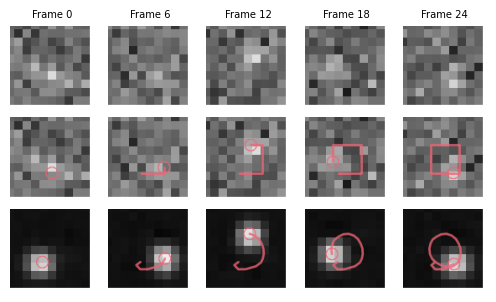

In [21]:
data_i, labels_i, latents_i, decodings_i = model_examples["square_kalmanSSL"]

video = data_i.cpu().numpy()
pos = labels_i["pos"].cpu().numpy()
noise_level = labels_i["noise_level"].cpu().numpy()
frames = get_video_frames(video, pos, pointer=False, colormap="gray")
frames_pointer = get_video_frames(video, pos, pointer=True, colormap="gray")

image_decoding = decodings_i["observations"].cpu().numpy()
position_decoding = decodings_i["pos"].cpu().numpy()
frames_model = get_video_frames(image_decoding, position_decoding, pointer=True, colormap="gray")

# plot the video
n_frames = 5
skipframes = 6
fig, axes = plt.subplots(3, n_frames, figsize=(n_frames * 1, 3))
for i in range(n_frames):
    axes[0,i].imshow(frames[i * skipframes])
    axes[0,i].axis("off")
    axes[0,i].set_title(f"Frame {i * skipframes}")
    axes[1,i].imshow(frames_pointer[i * skipframes])
    axes[1,i].axis("off")
    axes[2,i].imshow(frames_model[i * skipframes])
    axes[2,i].axis("off")
plt.tight_layout()
plt.savefig(plot_folder + f"circular_motion_videos_{model_name}_example{video_ind}.pdf", dpi=300)


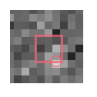

In [22]:
# plot single example trajectori
plt.figure(figsize=(1, 1))
plt.imshow(frames_pointer[i * skipframes])
plt.axis("off")
plt.savefig(plot_folder + f"circular_motion_trajectory_{model_name}_example{video_ind}.pdf", dpi=300)

Eigenvalues of A: [0.9522043+0.31183642j 0.9522043-0.31183642j]
Spectral radius of A: 1.0019655227661133


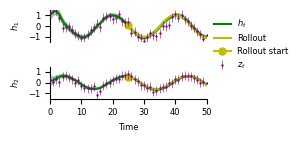

In [23]:
data_i, labels_i, latents_i, decodings_i = model_examples["square_kalmanSSL"]
data, labels, latents, decodings, model, cfg = model_dict["square_kalmanSSL"]
shift = 1 # model.prediction_shift

def plot_latent_trajectory(ax, dim, state, state_cov, inferences, inference_cov):
    ax.plot(state[:, dim], 'g', label=r'$h_t$')
    ax.fill_between(range(state.shape[0]-shift), 
                    (state[:-shift, dim] - 2 * np.sqrt(state_cov[:-shift, dim, dim])), 
                    (state[:-shift, dim] + 2 * np.sqrt(state_cov[:-shift, dim, dim])), 
                    color='g', alpha=0.3)
    ax.errorbar(range(inferences.shape[0]-shift),
                inferences[:-shift, dim], 
                yerr=np.sqrt(inference_cov[:-shift, dim, dim]) * 1.8,
                fmt='o', color='purple', alpha=1, label=r'$z_t$',
                markersize=0.7, linewidth=0.4, zorder=10)
    ax.set_xlim(0, 50)
    # ax.set_title(f'Dimension {dim}')


# Get final estimates
A = model.encoder.A.data.cpu().numpy()
# print(A)
print(f"Eigenvalues of A: {np.linalg.eigvals(A)}")
print(f"Spectral radius of A: {np.max(np.abs(np.linalg.eigvals(A)))}")
D = model.encoder.D.data.cpu().numpy()
b_z = model.encoder.b_z.data.cpu().numpy()
estimates = latents_i["estimates"].cpu().numpy() - b_z
estimates_latent = np.einsum('ij,tj->ti', D, estimates)
estimates_cov = latents_i["estimates_covariances"].cpu().numpy()
estimates_cov_latent = np.einsum('jk,ikl->ijl', D, np.einsum('ijk,kl->ijl', estimates_cov, D.T))
inferences = latents_i["inferences"].cpu().numpy() - np.dot(D, b_z)
inferences_cov = latents_i["inferences_covariances"].cpu().numpy()
predictions = latents_i["predictions"].cpu().numpy() - np.dot(D, b_z)
prediction_cov = latents_i["prediction_covariances"].cpu().numpy()

sim_start = 25
n_steps = estimates.shape[0]
simulated_states_steps = np.arange(sim_start, n_steps)
simulated_states = np.zeros((n_steps-sim_start, estimates.shape[1]))
simulated_states[0] = estimates[sim_start]
for t in range(n_steps-1-sim_start):
    simulated_states[t+1] = A @ simulated_states[t]  
simulated_states = np.einsum('ij,tj->ti', D, simulated_states)

    
# Plot results
n = 2
fig, ax = plt.subplots(n, 1, figsize=(P_width, P_height*n))

for i in range(n):
    plot_latent_trajectory(ax[i], i, estimates_latent, estimates_cov_latent, inferences, inferences_cov)
    ax[i].plot(simulated_states_steps[:-shift], simulated_states[:-shift, i], color='y', label='Rollout')
    ax[i].plot(simulated_states_steps[:-shift][0], simulated_states[:-shift, i][0], color='y', marker='o', markersize=5,label='Rollout start')

    ax[i].set_ylabel(r'$h_{}$'.format(i+1))
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    if i < n-1:
        ax[i].spines['bottom'].set_visible(False)
        ax[i].set_xticks([])
    else:
        ax[i].set_xlabel('Time')
ax[0].legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)

ax[0].set_ylim(-1.5,1.5)
ax[1].set_ylim(-1.5,1.5)

plt.tight_layout()
plt.savefig(plot_folder + "latent_trajectory_square_kalmanSSL.pdf", bbox_inches='tight')

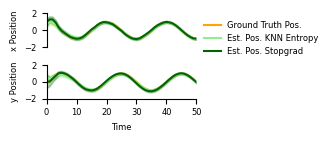

In [24]:

data_i, labels_i, latents_i, decodings_i = model_examples["square_kalmanSSL"]
pos = labels_i["sin_pos"].cpu().numpy()
fig, ax = plt.subplots(2, 1, figsize=(P_width*1.1, P_height*2))
ax[0].plot(pos[:, 0], 'orange', label='Ground Truth Pos.')
ax[1].plot(pos[:, 1], 'orange', label='Ground Truth Pos.')

for key in ["square_kalmanSSL_procrustes", "square_kalmanSSL"]:
    data_i, labels_i, latents_i, decodings_i = model_examples[key]
    data, labels, latents, decodings, model, cfg = model_dict[key]
    b_z = model.encoder.b_z.data.cpu().numpy()
    estimates = latents_i["estimates"].cpu().numpy() - b_z
    estimates_cov = latents_i["estimates_covariances"].cpu().numpy()
    pos_inferred = labels_i["sin_pos"].cpu().numpy()
    # plot decodings of labels
    pos_decoding_matrix = model.decoder.decoders["sin_pos"].linear.weight.data.cpu().numpy()
    bias = model.decoder.decoders["sin_pos"].linear.bias.data.cpu().numpy()
    pos_decoding = (pos_decoding_matrix @ estimates.T).T
    pos_decoding_cov = np.einsum('jk,ikl->ijl', pos_decoding_matrix, np.einsum('ijk,kl->ijl', estimates_cov, pos_decoding_matrix.T))
    color = 'lightgreen' if key == "square_kalmanSSL_procrustes" else 'darkgreen'
    suffix = 'Stopgrad' if key == "square_kalmanSSL" else 'KNN Entropy'
    ax[0].plot(pos_decoding[:, 0], color, label='Est. Pos. ' + suffix)
    ax[0].fill_between(range(pos_decoding.shape[0]),
                        (pos_decoding[:, 0] - 2 * np.sqrt(pos_decoding_cov[:, 0, 0])), 
                        (pos_decoding[:, 0] + 2 * np.sqrt(pos_decoding_cov[:, 0, 0])), 
                        color=color, alpha=0.3)
    ax[1].plot(pos_decoding[:, 1], color, label='Est. Pos.' + suffix)
    ax[1].fill_between(range(pos_decoding.shape[0]),
                        (pos_decoding[:, 1] - 2 * np.sqrt(pos_decoding_cov[:, 1, 1])), 
                        (pos_decoding[:, 1] + 2 * np.sqrt(pos_decoding_cov[:, 1, 1])), 
                        color=color, alpha=0.3)
    
ax[0].legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
ax[0].set_ylim(-2,2)
ax[1].set_ylim(-2,2)
ax[0].set_xlim(0, 50)
ax[1].set_xlim(0, 50)
ax[1].set_xlabel('Time')
ax[0].set_ylabel(r'x Position')
ax[1].set_ylabel(r'y Position')
ax[0].set_xticks([])
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['bottom'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(plot_folder + "position_estimates_square_kalmanSSL.pdf", bbox_inches='tight')

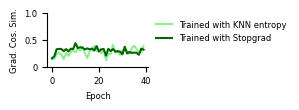

In [25]:
# plot learning curves from wandb
import wandb
import pandas as pd

# get wandb api key
wandb.login()
api = wandb.Api()

def get_cos_sim(model_name):
    # get the project name
    project_name = "probSSL"
    folder_name = "../trained_models/" + model_name + "/"
    # get name of the most recent model by folder creation time
    name = sorted(os.listdir(folder_name), key=lambda x: os.path.getctime(os.path.join(folder_name, x)))[-1]
    run = api.run(f"{project_name}/{name}")
    metrics = run.history()
    cos_sim = metrics["grad_cos_sim"]
    # remove nan values
    cos_sim = [x for x in cos_sim if not pd.isna(x)]
    return cos_sim

cos_sim_proc = get_cos_sim("square_kalmanSSL_procrustes")
cos_sim_stop = get_cos_sim("square_kalmanSSL")

plt.figure(figsize=(1.3,0.7))
plt.plot(cos_sim_proc, label='Trained with KNN entropy', color='lightgreen')
plt.plot(cos_sim_stop, label='Trained with Stopgrad', color='darkgreen')
# remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlabel("Epoch")
plt.ylabel("Grad. Cos. Sim.")
plt.yticks(ticks=[0, 0.5, 1.0], labels=[0, 0.5, 1.0])
# legend outside
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
plt.savefig(plot_folder + "grad_cos_sim_square.pdf", bbox_inches='tight')

Eigenvalues of A: [0.925777+0.3011849j 0.925777-0.3011849j]
Spectral radius of A: 0.9735376238822937


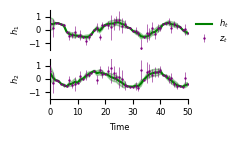

In [26]:
data_i, labels_i, latents_i, decodings_i = model_examples["kalmanSSL_inferred_sigmas"]
data, labels, latents, decodings, model, cfg = model_dict["kalmanSSL_inferred_sigmas"]
shift = 1 # model.prediction_shift

def plot_latent_trajectory(ax, dim, state, state_cov, inferences, inference_cov):
    ax.plot(state[:, dim], 'g', label=r'$h_t$')
    ax.fill_between(range(state.shape[0]-shift), 
                    (state[:-shift, dim] - 2 * np.sqrt(state_cov[:-shift, dim, dim])), 
                    (state[:-shift, dim] + 2 * np.sqrt(state_cov[:-shift, dim, dim])), 
                    color='g', alpha=0.3)
    ax.errorbar(range(inferences.shape[0]-shift),
                inferences[:-shift, dim], 
                yerr=np.sqrt(inference_cov[:-shift, dim, dim]) * 1.8,
                fmt='o', color='purple', alpha=1, label=r'$z_t$',
                markersize=0.7, linewidth=0.4, zorder=10)
    ax.set_xlim(0, 50)
    # ax.set_title(f'Dimension {dim}')


# Get final estimates
A = model.encoder.A.data.cpu().numpy()
# print(A)
print(f"Eigenvalues of A: {np.linalg.eigvals(A)}")
print(f"Spectral radius of A: {np.max(np.abs(np.linalg.eigvals(A)))}")
D = model.encoder.D.data.cpu().numpy()
b_z = model.encoder.b_z.data.cpu().numpy()
estimates = latents_i["estimates"].cpu().numpy() - b_z
estimates_latent = np.einsum('ij,tj->ti', D, estimates)
estimates_cov = latents_i["estimates_covariances"].cpu().numpy()
estimates_cov_latent = np.einsum('jk,ikl->ijl', D, np.einsum('ijk,kl->ijl', estimates_cov, D.T))
inferences = latents_i["inferences"].cpu().numpy() - np.dot(D, b_z)
inferences_cov = latents_i["inferences_covariances"].cpu().numpy()
predictions = latents_i["predictions"].cpu().numpy() - np.dot(D, b_z)
prediction_cov = latents_i["prediction_covariances"].cpu().numpy()

sim_start = 25
n_steps = estimates.shape[0]
simulated_states_steps = np.arange(sim_start, n_steps)
simulated_states = np.zeros((n_steps-sim_start, estimates.shape[1]))
simulated_states[0] = estimates[sim_start]
for t in range(n_steps-1-sim_start):
    simulated_states[t+1] = A @ simulated_states[t]  
simulated_states = np.einsum('ij,tj->ti', D, simulated_states)

    
# Plot results
n = 2
fig, ax = plt.subplots(n, 1, figsize=(P_width*0.8, P_height*n))

for i in range(n):
    plot_latent_trajectory(ax[i], i, estimates_latent, estimates_cov_latent, inferences, inferences_cov)
    # ax[i].plot(simulated_states_steps[:-shift], simulated_states[:-shift, i], color='y', label='Rollout')
    # ax[i].plot(simulated_states_steps[:-shift][0], simulated_states[:-shift, i][0], color='y', marker='o', markersize=5,label='Rollout start')

    ax[i].set_ylabel(r'$h_{}$'.format(i+1))
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    if i < n-1:
        ax[i].spines['bottom'].set_visible(False)
        ax[i].set_xticks([])
    else:
        ax[i].set_xlabel('Time')
ax[0].legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)

ax[0].set_ylim(-1.5,1.5)
ax[1].set_ylim(-1.5,1.5)

plt.tight_layout()
plt.savefig(plot_folder + "latent_states_inferred.pdf", bbox_inches='tight')

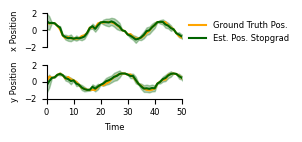

In [27]:

fig, ax = plt.subplots(2, 1, figsize=(P_width, P_height*2))

data_i, labels_i, latents_i, decodings_i = model_examples["kalmanSSL_inferred_sigmas"]
data, labels, latents, decodings, model, cfg = model_dict["kalmanSSL_inferred_sigmas"]

pos = labels_i["pos"].cpu().numpy()
ax[0].plot(pos[:, 0], 'orange', label='Ground Truth Pos.')
ax[1].plot(pos[:, 1], 'orange', label='Ground Truth Pos.')

b_z = model.encoder.b_z.data.cpu().numpy()
estimates = latents_i["estimates"].cpu().numpy() - b_z
pos_inferred = labels_i["pos"].cpu().numpy()
# plot decodings of labels
pos_decoding_matrix = model.decoder.decoders["pos"].linear.weight.data.cpu().numpy()
bias = model.decoder.decoders["pos"].linear.bias.data.cpu().numpy()
pos_decoding = (pos_decoding_matrix @ estimates.T).T
pos_decoding_cov = np.einsum('jk,ikl->ijl', pos_decoding_matrix, np.einsum('ijk,kl->ijl', estimates_cov, pos_decoding_matrix.T))
color = 'darkgreen'
suffix = 'Stopgrad' 
ax[0].plot(pos_decoding[:, 0], color, label='Est. Pos. ' + suffix)
ax[0].fill_between(range(pos_decoding.shape[0]),
                    (pos_decoding[:, 0] - 2 * np.sqrt(pos_decoding_cov[:, 0, 0])), 
                    (pos_decoding[:, 0] + 2 * np.sqrt(pos_decoding_cov[:, 0, 0])), 
                    color=color, alpha=0.3)
ax[1].plot(pos_decoding[:, 1], color, label='Est. Pos.' + suffix)
ax[1].fill_between(range(pos_decoding.shape[0]),
                    (pos_decoding[:, 1] - 2 * np.sqrt(pos_decoding_cov[:, 1, 1])), 
                    (pos_decoding[:, 1] + 2 * np.sqrt(pos_decoding_cov[:, 1, 1])), 
                    color=color, alpha=0.3)
    
ax[0].legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
ax[0].set_ylim(-2,2)
ax[1].set_ylim(-2,2)
ax[0].set_xlim(0, 50)
ax[1].set_xlim(0, 50)
ax[1].set_xlabel('Time')
ax[0].set_ylabel(r'x Position')
ax[1].set_ylabel(r'y Position')
ax[0].set_xticks([])
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['bottom'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(plot_folder + "position_decoding_inferred.pdf", bbox_inches='tight')

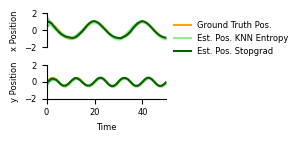

In [28]:

data_i, labels_i, latents_i, decodings_i = model_examples["kalmanSSL_figure8"]
pos = labels_i["pos"].cpu().numpy()
fig, ax = plt.subplots(2, 1, figsize=(P_width, P_height*2))
ax[0].plot(pos[:, 0], 'orange', label='Ground Truth Pos.')
ax[1].plot(pos[:, 1], 'orange', label='Ground Truth Pos.')

for key in ["kalmanSSL_figure8_procrustes", "kalmanSSL_figure8"]:
    data_i, labels_i, latents_i, decodings_i = model_examples[key]
    data, labels, latents, decodings, model, cfg = model_dict[key]
    b_z = model.encoder.b_z.data.cpu().numpy()
    estimates = latents_i["estimates"].cpu().numpy() - b_z
    estimates_cov = latents_i["estimates_covariances"].cpu().numpy()
    pos_inferred = labels_i["pos"].cpu().numpy()
    # plot decodings of labels
    pos_decoding_matrix = model.decoder.decoders["pos"].linear.weight.data.cpu().numpy()
    bias = model.decoder.decoders["pos"].linear.bias.data.cpu().numpy()
    pos_decoding = (pos_decoding_matrix @ estimates.T).T
    pos_decoding_cov = np.einsum('jk,ikl->ijl', pos_decoding_matrix, np.einsum('ijk,kl->ijl', estimates_cov, pos_decoding_matrix.T))
    color = 'lightgreen' if key == "kalmanSSL_figure8_procrustes" else 'darkgreen'
    suffix = 'Stopgrad' if key == "kalmanSSL_figure8" else 'KNN Entropy'
    ax[0].plot(pos_decoding[:, 0], color, label='Est. Pos. ' + suffix)
    ax[0].fill_between(range(pos_decoding.shape[0]),
                        (pos_decoding[:, 0] - 2 * np.sqrt(pos_decoding_cov[:, 0, 0])), 
                        (pos_decoding[:, 0] + 2 * np.sqrt(pos_decoding_cov[:, 0, 0])), 
                        color=color, alpha=0.3)
    ax[1].plot(pos_decoding[:, 1], color, label='Est. Pos.' + suffix)
    ax[1].fill_between(range(pos_decoding.shape[0]),
                        (pos_decoding[:, 1] - 2 * np.sqrt(pos_decoding_cov[:, 1, 1])), 
                        (pos_decoding[:, 1] + 2 * np.sqrt(pos_decoding_cov[:, 1, 1])), 
                        color=color, alpha=0.3)
    
ax[0].legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
ax[0].set_ylim(-2,2)
ax[1].set_ylim(-2,2)
ax[0].set_xlim(0, 50)
ax[1].set_xlim(0, 50)
ax[1].set_xlabel('Time')
ax[0].set_ylabel(r'x Position')
ax[1].set_ylabel(r'y Position')
ax[0].set_xticks([])
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['bottom'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(plot_folder + "position_decoding_figure8.pdf", bbox_inches='tight')

In [32]:
# r2 score of position decoding from latents of all models
from sklearn.metrics import r2_score

for model_name, tpl in model_examples.items():
    try:
        data_i, labels_i, latents_i, decodings_i = tpl
        data, labels, latents, decodings, model, cfg = model_dict[model_name]
        b_z = model.encoder.b_z.data.cpu().numpy()
        estimates = latents_i["estimates"].cpu().numpy() - b_z
        pos_inferred = labels_i["pos"].cpu().numpy()
        # plot decodings of labels
        pos_decoding_matrix = model.decoder.decoders["pos"].linear.weight.data.cpu().numpy()
        bias = model.decoder.decoders["pos"].linear.bias.data.cpu().numpy()
        pos_decoding = (pos_decoding_matrix @ estimates.T).T
        r2 = r2_score(pos_inferred, pos_decoding)
        print(f"Model: {model_name}, R2 : {r2:.3f}")
    except Exception as e:
        print(f"Model: {model_name}, Error: {e}")

Model: kalmanSSL_inferred_sigmas, R2 : 0.959
Model: kalmanSSL_figure8_procrustes, R2 : 0.991
Model: kalmanSSL_figure8, R2 : 0.990
Model: square_kalmanSSL_procrustes, Error: 'MLPDecoder' object has no attribute 'linear'
Model: square_kalmanSSL, R2 : 0.967


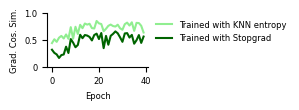

In [30]:
# plot learning curves from wandb
import wandb
import pandas as pd

# get wandb api key
wandb.login()
api = wandb.Api()

def get_cos_sim(model_name):
    # get the project name
    project_name = "probSSL"
    folder_name = "../trained_models/" + model_name + "/"
    # get name of the most recent model by folder creation time
    name = sorted(os.listdir(folder_name), key=lambda x: os.path.getctime(os.path.join(folder_name, x)))[-1]
    run = api.run(f"{project_name}/{name}")
    metrics = run.history()
    cos_sim = metrics["grad_cos_sim"]
    # remove nan values
    cos_sim = [x for x in cos_sim if not pd.isna(x)]
    return cos_sim

cos_sim_proc = get_cos_sim("kalmanSSL_figure8_procrustes")
cos_sim_stop = get_cos_sim("kalmanSSL_figure8")

plt.figure(figsize=(1.3,0.7))
plt.plot(cos_sim_proc, label='Trained with KNN entropy', color='lightgreen')
plt.plot(cos_sim_stop, label='Trained with Stopgrad', color='darkgreen')
# remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlabel("Epoch")
plt.ylabel("Grad. Cos. Sim.")
plt.yticks(ticks=[0, 0.5, 1.0], labels=[0, 0.5, 1.0])
# legend outside
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
plt.savefig(plot_folder + "grad_cos_sim_figure8.pdf", bbox_inches='tight')
